# 🧠 The Self-Pruning Neural Network
## Tredence Analytics — AI Engineering Internship Case Study
### Allaudin Ansari

---

| Field | Detail |
|---|---|
| **Dataset** | CIFAR-10 (60,000 images, 10 classes) |
| **Framework** | PyTorch |
| **Environment** | Google Colab (T4 / A100 GPU) |
| **Core Technique** | Learnable sigmoid gates + L1 sparsity regularisation |
| **λ experiments** | 3 values: Low / Medium / High |

---

## Notebook Structure

| Section | Content |
|---|---|
| **§0** | Environment, Drive mount, seeds, logging |
| **§1** | CIFAR-10 data pipeline |
| **§2** | `PrunableLinear` — the core custom layer |
| **§3** | `SelfPruningNet` architecture |
| **§4** | Gradient flow verification |
| **§5** | Training infrastructure (CheckpointManager, BestModelSaver, ExperimentLogger) |
| **§6** | Loss functions + training loop |
| **§7** | Experiment 1 — Low λ |
| **§8** | Experiment 2 — Medium λ |
| **§9** | Experiment 3 — High λ |
| **§10** | Results table (Tredence required) |
| **§11** | Gate distribution plot (Tredence required) |
| **§12** | Training curves + sparsity evolution |
| **§13** | Markdown report (embedded) |


---
## §0 — Environment Setup


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# §0.1 — Drive mount + directory structure
# All checkpoints, logs, figures, and results are persisted to Google Drive so
# training can be resumed after any Colab session timeout.
# ─────────────────────────────────────────────────────────────────────────────
import os, sys, json, csv, time, math, random, logging, datetime, warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any
from dataclasses import dataclass, field, asdict

IN_COLAB = 'COLAB_GPU' in os.environ
if IN_COLAB:
    try:
        get_ipython()
    except NameError:
        IN_COLAB = False
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT = '/content/drive/MyDrive/Tredence'
    DATA_ROOT    = '/tmp/tredence_data'          # runtime storage (fast, free)
else:
    PROJECT_ROOT = os.path.abspath('Tredence')
    DATA_ROOT    = os.path.join(PROJECT_ROOT, 'data')

DIRS = {
    'root':        PROJECT_ROOT,
    'checkpoints': os.path.join(PROJECT_ROOT, 'checkpoints'),
    'best_models': os.path.join(PROJECT_ROOT, 'best_models'),
    'logs':        os.path.join(PROJECT_ROOT, 'logs'),
    'figures':     os.path.join(PROJECT_ROOT, 'figures'),
    'results':     os.path.join(PROJECT_ROOT, 'results'),
    'data':        DATA_ROOT,
}
for p in DIRS.values():
    try:
        os.makedirs(p, exist_ok=True)
    except OSError as e:
        print(f'Warning: Could not create directory {p}: {e}')

print('✅ Directory structure ready.')
for k, v in DIRS.items():
    print(f'   {k:<15} {v}')


Mounted at /content/drive
✅ Directory structure ready.
   root            /content/drive/MyDrive/Tredence
   checkpoints     /content/drive/MyDrive/Tredence/checkpoints
   best_models     /content/drive/MyDrive/Tredence/best_models
   logs            /content/drive/MyDrive/Tredence/logs
   figures         /content/drive/MyDrive/Tredence/figures
   results         /content/drive/MyDrive/Tredence/results
   data            /tmp/tredence_data


In [2]:
# §0.2 — All imports
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import torchvision.datasets as datasets
from tqdm.auto import tqdm
warnings.filterwarnings('ignore', category=UserWarning)

def get_device():
    if torch.cuda.is_available():          return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
                                           return torch.device('mps')
    return torch.device('cpu')

DEVICE = get_device()
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    gpu  = torch.cuda.get_device_name(0)
    mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✅ GPU: {gpu}  |  Mem: {mem:.1f} GB')
else:
    print(f'✅ Device: {DEVICE}  (tip: Runtime → T4 GPU for faster training)')
print(f'   PyTorch {torch.__version__}')


✅ GPU: Tesla T4  |  Mem: 15.6 GB
   PyTorch 2.10.0+cu128


In [3]:
# §0.3 — Reproducibility seeds
GLOBAL_SEED = 42

def set_global_seeds(seed: int = GLOBAL_SEED) -> None:
    """Set seeds for Python, NumPy, PyTorch CPU/CUDA — guarantees reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
    os.environ['PYTHONHASHSEED'] = str(seed)

set_global_seeds()
print(f'✅ Global seed set to {GLOBAL_SEED}')


✅ Global seed set to 42


In [4]:
# §0.4 — Dual-sink logger
# Writes INFO to console and DEBUG to a timestamped .log file on Drive.
# Every training event is permanently recorded even after session reset.

def setup_logger(name: str = 'SelfPruning', log_dir: str = DIRS['logs']) -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(logging.DEBUG)
    if logger.handlers:
        logger.handlers.clear()
    # Console — INFO and above
    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(logging.Formatter('[%(asctime)s | %(levelname)-8s] %(message)s', '%H:%M:%S'))
    # File — DEBUG and above (full trace)
    ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    fh = logging.FileHandler(os.path.join(log_dir, f'{name}_{ts}.log'), encoding='utf-8')
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(logging.Formatter('%(asctime)s|%(levelname)-8s|%(funcName)s:%(lineno)d|%(message)s'))
    logger.addHandler(ch)
    logger.addHandler(fh)
    return logger

LOG = setup_logger()
LOG.info('Self-Pruning Neural Network — Tredence Case Study started.')
print('✅ Logger ready (console + Drive log file)')


[12:16:56 | INFO    ] Self-Pruning Neural Network — Tredence Case Study started.


INFO:SelfPruning:Self-Pruning Neural Network — Tredence Case Study started.


✅ Logger ready (console + Drive log file)


In [5]:
# §0.5 — Master Configuration
#
# All hyperparameters are centralised here. The config is saved as config.json
# alongside every checkpoint so each run is fully self-describing.
#
# Key design decisions:
#   gate_init_std = 1.0   → gates span ~(0.27, 0.73) at init, breaking
#                           the symmetric equilibrium that causes 0% sparsity.
#   gate_lr       = 1e-2  → separate Adam group for gate_scores at 10× the
#                           weight lr; Adam's adaptive scaling otherwise
#                           dampens the tiny gate gradient to near-zero.
#   weight_decay  = 0     → applied to weights only, not gate_scores; L2 on
#                           gates pins sigmoid(0)=0.5, fighting the L1 loss.
#   use_batchnorm = False → BatchNorm between layers suppresses ∂CE/∂gate
#                           by re-normalising activations, so gate changes
#                           never propagate to the classification loss.
#   warmup = 3 epochs     → ramp λ from 0 to target; prevents gates from
#                           collapsing before useful features are learned.
#   lambdas = [2e-8, 1e-7, 5e-7]
#             Three λ values spanning a low/medium/high sparsity regime.
#             SparsityLoss = SUM of all gate values ≈ 852,608 at init.
#             Per-gate gradient = λ × σ(g)(1-σ(g)) ≈ λ × 0.25.

@dataclass
class Config:
    seed: int = GLOBAL_SEED

    # Dataset
    dataset_name: str = 'CIFAR-10'
    num_classes:  int = 10
    image_size:   int = 32
    num_channels: int = 3
    cifar_mean: Tuple[float, float, float] = (0.4914, 0.4822, 0.4465)
    cifar_std:  Tuple[float, float, float] = (0.2470, 0.2435, 0.2616)

    # DataLoader
    batch_size_train: int  = 128
    batch_size_test:  int  = 256
    num_workers:      int  = 2
    pin_memory:       bool = True

    # Architecture
    input_dim:   int   = 3072          # 3 × 32 × 32 flattened
    hidden1_dim: int   = 1024
    hidden2_dim: int   = 256
    output_dim:  int   = 10
    dropout_p:   float = 0.10
    # BatchNorm removed between PrunableLinear layers: BN re-normalises
    # activations after each layer, so a gate shifting 0.5→0.05 has almost
    # no effect on the downstream CE loss, killing ∂CE/∂gate feedback.
    use_batchnorm: bool = False

    # Gate initialisation
    gate_init_mean: float = 0.0
    gate_init_std:  float = 1.0        # N(0,1) → gates span ~(0.27,0.73) at init

    # Training
    epochs:       int   = 50
    lr:           float = 1e-3         # weights + biases learning rate
    gate_lr:      float = 1e-2         # gate_scores learning rate (10× weight lr)
    weight_decay: float = 1e-4         # applied to weights only, not gate_scores
    grad_clip:    float = 1.0

    # ── Lambda experiments ────────────────────────────────────────────────────
    # SparsityLoss = SUM of all sigmoid(gate_scores) across all PrunableLinear
    # layers (Tredence spec, Part 2). At init ≈ 852,608 (N_gates × 0.5).
    # Per-gate gradient from SparsityLoss = λ × σ(g)(1-σ(g)) ≈ λ × 0.25.
    #   Low    2e-8: gate_grad ≈ 5e-9   — gentle pressure, accuracy preserved
    #   Medium 1e-7: gate_grad ≈ 2.5e-8 — balanced accuracy-sparsity trade-off
    #   High   5e-7: gate_grad ≈ 1.25e-7— aggressive pruning
    lambdas: List[float] = field(default_factory=lambda: [2e-8, 1e-7, 5e-7])
    lambda_labels: List[str] = field(
        default_factory=lambda: ['Low (2e-8)', 'Medium (1e-7)', 'High (5e-7)'])

    # Lambda warmup: ramp 0 → λ linearly over first warmup_epochs epochs.
    # Prevents gates from being forced to zero before the network learns any
    # useful class representations.
    lambda_warmup_epochs: int = 3

    # Pruning evaluation
    sparsity_threshold: float = 1e-2   # gate < 0.01 → weight counted as pruned
    ste_threshold:      float = 0.5    # hard-gate threshold for STE evaluation

    # Checkpointing
    checkpoint_every_n_epochs: int      = 5
    keep_top_k_checkpoints:    int      = 1
    gate_snapshot_epochs: List[int]     = field(
        default_factory=lambda: [1, 5, 10, 20, 30, 35, 40, 45, 50])

    # Paths (refreshed at runtime)
    project_root:    str = PROJECT_ROOT
    checkpoint_dir:  str = DIRS['checkpoints']
    best_models_dir: str = DIRS['best_models']
    log_dir:         str = DIRS['logs']
    figures_dir:     str = DIRS['figures']
    results_dir:     str = DIRS['results']
    data_dir:        str = DIRS['data']

    def to_json(self, path: str) -> None:
        with open(path, 'w') as f:
            json.dump(asdict(self), f, indent=2)

    @classmethod
    def from_json(cls, path: str) -> 'Config':
        with open(path) as f:
            data = json.load(f)
        return cls(**{k: v for k, v in data.items() if k in cls.__dataclass_fields__})

    def refresh_paths(self) -> None:
        """Overwrite stored paths with live DIRS (handles Colab session changes)."""
        self.checkpoint_dir  = DIRS['checkpoints']
        self.best_models_dir = DIRS['best_models']
        self.log_dir         = DIRS['logs']
        self.figures_dir     = DIRS['figures']
        self.results_dir     = DIRS['results']
        self.data_dir        = DIRS['data']


# Always create a fresh config so stale values from previous runs are not loaded.
CFG = Config()
config_json = os.path.join(DIRS['root'], 'config.json')
CFG.to_json(config_json)
print('✅ Config created and saved.')
print()
print(f'   epochs           : {CFG.epochs}')
print(f'   lambdas          : {CFG.lambdas}')
print(f'   lambda_labels    : {CFG.lambda_labels}')
print(f'   gate_lr          : {CFG.gate_lr}  (10× weight lr)')
print(f'   weight_decay     : {CFG.weight_decay}  (weights only, not gate_scores)')
print(f'   use_batchnorm    : {CFG.use_batchnorm}')
print(f'   warmup_epochs    : {CFG.lambda_warmup_epochs}')
print(f'   gate_init_std    : {CFG.gate_init_std}')
print(f'   sparsity_thr     : {CFG.sparsity_threshold}')
print()
N_GATES_TOTAL = CFG.input_dim*CFG.hidden1_dim + CFG.hidden1_dim*CFG.hidden2_dim + CFG.hidden2_dim*CFG.output_dim
SP_INIT = N_GATES_TOTAL * 0.5
CE_INIT = 1.6
print(f'   Total gate params  : {N_GATES_TOTAL:,}')
print(f'   SparsityLoss (SUM) : ≈ {SP_INIT:,.0f} at init')
print()
print('   Lambda calibration (per-gate gradient from SparsityLoss):')
for lam, label in zip(CFG.lambdas, CFG.lambda_labels):
    grad_gate = lam * 0.25
    pct = lam * SP_INIT / CE_INIT * 100
    print(f'     {label:<22}  gate_grad≈{grad_gate:.2e}  λ×SP={lam*SP_INIT:,.2f}  ({pct:.2f}% of CE)')


✅ Config created and saved.

   epochs           : 50
   lambdas          : [2e-08, 1e-07, 5e-07]
   lambda_labels    : ['Low (2e-8)', 'Medium (1e-7)', 'High (5e-7)']
   gate_lr          : 0.01  (10× weight lr)
   weight_decay     : 0.0001  (weights only, not gate_scores)
   use_batchnorm    : False
   warmup_epochs    : 3
   gate_init_std    : 1.0
   sparsity_thr     : 0.01

   Total gate params  : 3,410,432
   SparsityLoss (SUM) : ≈ 1,705,216 at init

   Lambda calibration (per-gate gradient from SparsityLoss):
     Low (2e-8)              gate_grad≈5.00e-09  λ×SP=0.03  (2.13% of CE)
     Medium (1e-7)           gate_grad≈2.50e-08  λ×SP=0.17  (10.66% of CE)
     High (5e-7)             gate_grad≈1.25e-07  λ×SP=0.85  (53.29% of CE)


---
## §1 — CIFAR-10 Data Pipeline


In [6]:
# §1.1 — Transforms + DataLoaders
# Train: RandomCrop, HorizontalFlip, ColorJitter, Normalize
# Test:  ToTensor, Normalize only (no augmentation)

train_transform = T.Compose([
    T.RandomCrop(CFG.image_size, padding=4),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=CFG.cifar_mean, std=CFG.cifar_std),
])
test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=CFG.cifar_mean, std=CFG.cifar_std),
])

train_dataset = datasets.CIFAR10(root=CFG.data_dir, train=True,  download=True, transform=train_transform)
test_dataset  = datasets.CIFAR10(root=CFG.data_dir, train=False, download=True, transform=test_transform)

CIFAR10_CLASSES = train_dataset.classes

g = torch.Generator()
g.manual_seed(CFG.seed)
TRAIN_LOADER = DataLoader(
    train_dataset, batch_size=CFG.batch_size_train,
    shuffle=True, num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory and DEVICE.type == 'cuda',
    drop_last=True, generator=g, persistent_workers=CFG.num_workers > 0)
TEST_LOADER = DataLoader(
    test_dataset, batch_size=CFG.batch_size_test,
    shuffle=False, num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory and DEVICE.type == 'cuda',
    persistent_workers=CFG.num_workers > 0)

print(f'✅ DataLoaders ready')
print(f'   Train: {len(train_dataset):,} samples | {len(TRAIN_LOADER)} batches × {CFG.batch_size_train}')
print(f'   Test : {len(test_dataset):,} samples  | {len(TEST_LOADER)} batches × {CFG.batch_size_test}')
imgs, lbls = next(iter(TRAIN_LOADER))
print(f'   Batch shape: {tuple(imgs.shape)}  |  pixel range [{imgs.min():.2f}, {imgs.max():.2f}]')


100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


✅ DataLoaders ready
   Train: 50,000 samples | 390 batches × 128
   Test : 10,000 samples  | 40 batches × 256
   Batch shape: (128, 3, 32, 32)  |  pixel range [-1.99, 2.13]


---
## §2 — `PrunableLinear` Custom Layer

> **Tredence Requirement (Part 1):** Custom linear layer with learnable `gate_scores`.  
> Forward pass: `gates = sigmoid(gate_scores)` → `pruned_weights = weight * gates` → `F.linear(x, pruned_weights, bias)`


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# §2.1 — PrunableLinear
#
# This is the core building block of the entire project.
# It replaces torch.nn.Linear completely.
#
# Each weight w_ij has a paired learnable scalar gate_score g_ij.
# The effective weight used in the forward pass is:
#
#     effective_w_ij = w_ij × sigmoid(g_ij)
#
# When the sparsity loss drives sigmoid(g_ij) → 0, the weight is effectively
# removed from the network.  This happens during training — no post-training
# pruning step needed.
#
# Gradient flow:
#   ∂L/∂weight     = ∂L/∂output × sigmoid(gate_scores)      ✅ non-zero
#   ∂L/∂gate_scores = ∂L/∂output × weight × sigmoid'(g) × 1  ✅ non-zero
#   Both gradients flow automatically via PyTorch autograd.
# ─────────────────────────────────────────────────────────────────────────────

class PrunableLinear(nn.Module):
    """
    Drop-in replacement for nn.Linear with per-weight learnable sigmoid gates.

    Args:
        in_features:    Number of input features.
        out_features:   Number of output features.
        bias:           Whether to include a bias term (default: True).
        gate_init_mean: Mean for gate_scores initialisation (default: 0.0).
        gate_init_std:  Std  for gate_scores initialisation (default: 1.0).
                        std=1.0 gives gates in ~(0.27, 0.73) at init,
                        breaking the symmetric equilibrium.

    Attributes:
        weight:      Learnable weight matrix (out_features, in_features).
        bias:        Learnable bias vector  (out_features,) or None.
        gate_scores: Learnable gate parameters — SAME SHAPE as weight.
    """

    def __init__(
        self,
        in_features:    int,
        out_features:   int,
        bias:           bool  = True,
        gate_init_mean: float = 0.0,
        gate_init_std:  float = 1.0,
    ) -> None:
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # Standard weight (Kaiming uniform — same as nn.Linear default)
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

        # Bias (uniform — same as nn.Linear default)
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)
        else:
            self.register_parameter('bias', None)

        # Gate scores — registered as nn.Parameter so the optimiser updates them
        # N(0, 1.0): gates span ~(0.27, 0.73) at init, not all stuck at 0.50
        self.gate_scores = nn.Parameter(
            torch.normal(mean=gate_init_mean, std=gate_init_std,
                         size=(out_features, in_features))
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Gated linear transformation.

        Steps:
          1. gates = sigmoid(gate_scores)        ∈ (0, 1) per weight
          2. pruned_weights = weight * gates      element-wise mask
          3. return F.linear(x, pruned_weights, bias)

        Both weight and gate_scores receive gradients via autograd.
        """
        gates          = torch.sigmoid(self.gate_scores)   # (out, in)
        pruned_weights = self.weight * gates               # element-wise
        return F.linear(x, pruned_weights, self.bias)

    # ── Utility helpers ───────────────────────────────────────────────────────

    def get_gates(self) -> torch.Tensor:
        """Current gate values in (0,1), detached from the computation graph."""
        return torch.sigmoid(self.gate_scores).detach()

    def get_sparsity(self, threshold: float = 1e-2) -> float:
        """Fraction of weights whose gate value < threshold (= 'pruned')."""
        g = self.get_gates()
        return (g < threshold).float().sum().item() / g.numel()

    def apply_hard_gates(self, threshold: float = 0.5) -> torch.Tensor:
        """STE binarisation: gate >= threshold → 1, else → 0 (detached)."""
        return (self.get_gates() >= threshold).float()

    def extra_repr(self) -> str:
        return (f'in={self.in_features}, out={self.out_features}, '
                f'gates={self.gate_scores.numel():,}')


# Quick sanity check
_l = PrunableLinear(8, 4).to(DEVICE)
g  = _l.get_gates()
print('✅ PrunableLinear defined.')
print(f'   Test layer (8→4): weight {tuple(_l.weight.shape)}, gate_scores {tuple(_l.gate_scores.shape)}')
print(f'   Init gate stats : mean={g.mean():.3f}, std={g.std():.3f}, '
      f'min={g.min():.3f}, max={g.max():.3f}')
del _l


✅ PrunableLinear defined.
   Test layer (8→4): weight (4, 8), gate_scores (4, 8)
   Init gate stats : mean=0.501, std=0.233, min=0.195, max=0.906


---
## §3 — `SelfPruningNet` Architecture

Architecture: `Flatten → PrunableLinear(3072→1024) → ReLU → Dropout`  
`→ PrunableLinear(1024→256) → ReLU → Dropout → PrunableLinear(256→10)`  
*(BatchNorm removed — see FIX 4 in §3 cell)*


In [8]:
# §3.1 — SelfPruningNet
#
# BatchNorm is not used between PrunableLinear layers. When BN follows a
# PrunableLinear layer it re-normalises activations to zero mean / unit
# variance, so a gate shifting from 0.5 → 0.05 has almost no effect on the
# downstream CE loss — ∂CE/∂gate_score ≈ 0. Removing BN restores the full
# classification gradient signal to every gate.
#
# SparsityLoss = Σ_{layers} Σ_{i,j} sigmoid(gate_scores_{ij})  [SUM-based L1 norm]
#   Each gate_score receives gradient: λ × σ(g)(1-σ(g)) ≈ λ × 0.25, uniform
#   across all layers regardless of layer size.

class SelfPruningNet(nn.Module):
    """
    Feed-forward CIFAR-10 classifier where every linear layer is a PrunableLinear.

    Architecture:
        Input (3×32×32)
          → Flatten (3072)
          → PrunableLinear(3072, 1024) → ReLU → Dropout(0.1)
          → PrunableLinear(1024, 256)  → ReLU → Dropout(0.1)
          → PrunableLinear(256, 10)    → logits
    """

    def __init__(self, cfg: Config) -> None:
        super().__init__()
        self.cfg     = cfg
        self.flatten = nn.Flatten()

        self.fc1   = PrunableLinear(cfg.input_dim,   cfg.hidden1_dim,
                                    gate_init_mean=cfg.gate_init_mean,
                                    gate_init_std=cfg.gate_init_std)
        self.drop1 = nn.Dropout(cfg.dropout_p)

        self.fc2   = PrunableLinear(cfg.hidden1_dim, cfg.hidden2_dim,
                                    gate_init_mean=cfg.gate_init_mean,
                                    gate_init_std=cfg.gate_init_std)
        self.drop2 = nn.Dropout(cfg.dropout_p)

        self.fc3   = PrunableLinear(cfg.hidden2_dim, cfg.output_dim,
                                    gate_init_mean=cfg.gate_init_mean,
                                    gate_init_std=cfg.gate_init_std)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        x = self.drop1(F.relu(self.fc1(x)))
        x = self.drop2(F.relu(self.fc2(x)))
        return self.fc3(x)

    def get_all_prunable_layers(self) -> List[Tuple[str, PrunableLinear]]:
        return [(n, m) for n, m in self.named_modules()
                if isinstance(m, PrunableLinear)]

    def compute_sparsity_loss(self) -> torch.Tensor:
        """
        SparsityLoss = Σ_{layers} Σ_{i,j} sigmoid(gate_scores_{ij})

        This is the L1 norm of all gate values. Since gates are always positive
        (sigmoid output ∈ (0,1)), the L1 norm equals the sum of all gate values.
        Each gate_score receives gradient λ × σ(g)(1-σ(g)) ≈ λ × 0.25, uniform
        across all layers regardless of layer size.

        Total Loss = CrossEntropyLoss + λ × SparsityLoss
        """
        dev  = next(self.parameters()).device
        loss = torch.tensor(0.0, device=dev)
        for _, layer in self.get_all_prunable_layers():
            loss = loss + torch.sigmoid(layer.gate_scores).sum()
        return loss

    def get_global_sparsity(self, threshold: float = None) -> Dict[str, float]:
        """Per-layer + global fraction of weights whose gate value < threshold."""
        thr   = threshold or self.cfg.sparsity_threshold
        stats = {}
        tp = tw = 0
        for name, layer in self.get_all_prunable_layers():
            g      = layer.get_gates()
            pruned = (g < thr).sum().item()
            total  = g.numel()
            stats[name] = pruned / total
            tp += pruned
            tw += total
        stats['global'] = tp / tw if tw > 0 else 0.0
        return stats

    def get_gate_snapshot(self) -> Dict[str, np.ndarray]:
        """Extract all gate values as a dict of NumPy arrays for saving/plotting."""
        return {name: layer.get_gates().cpu().numpy()
                for name, layer in self.get_all_prunable_layers()}

    def count_parameters(self) -> Dict[str, int]:
        total   = sum(p.numel() for p in self.parameters())
        gates   = sum(l.gate_scores.numel() for _, l in self.get_all_prunable_layers())
        weights = sum(l.weight.numel()      for _, l in self.get_all_prunable_layers())
        return {'total': total, 'weights_only': weights, 'gates_only': gates,
                'other': total - weights - gates}


# Architecture summary
_m  = SelfPruningNet(CFG).to(DEVICE)
pc  = _m.count_parameters()
print('✅ SelfPruningNet defined.')
print()
print('Parameter Breakdown:')
print(f'   Total parameters  : {pc["total"]:>12,}')
print(f'   Weight parameters : {pc["weights_only"]:>12,}')
print(f'   Gate parameters   : {pc["gates_only"]:>12,}  (learnable pruning masks)')
print(f'   Other (bias)      : {pc["other"]:>12,}')
print()
print('Per-layer gate stats at init:')
for name, layer in _m.get_all_prunable_layers():
    g = layer.get_gates()
    print(f'   {name}: {layer.gate_scores.numel():>10,} gates | '
          f'init: mean={g.mean():.3f}, std={g.std():.3f}')
sp_loss_init = _m.compute_sparsity_loss().item()
print()
print(f'   SparsityLoss at init (SUM) : {sp_loss_init:,.0f}')
for lam, label in zip(CFG.lambdas, CFG.lambda_labels):
    grad = lam * 0.25
    print(f'   {label}: λ×SP={lam*sp_loss_init:,.2f}  gate_grad≈{grad:.2e}')
_x = torch.randn(4, 3, 32, 32, device=DEVICE)
assert _m(_x).shape == (4, 10)
print()
print(f'✅ Forward pass: (4,3,32,32) → (4,10) ✓')
del _m, _x


✅ SelfPruningNet defined.

Parameter Breakdown:
   Total parameters  :    6,822,154
   Weight parameters :    3,410,432
   Gate parameters   :    3,410,432  (learnable pruning masks)
   Other (bias)      :        1,290

Per-layer gate stats at init:
   fc1:  3,145,728 gates | init: mean=0.500, std=0.208
   fc2:    262,144 gates | init: mean=0.500, std=0.208
   fc3:      2,560 gates | init: mean=0.497, std=0.206

   SparsityLoss at init (SUM) : 1,705,631
   Low (2e-8): λ×SP=0.03  gate_grad≈5.00e-09
   Medium (1e-7): λ×SP=0.17  gate_grad≈2.50e-08
   High (5e-7): λ×SP=0.85  gate_grad≈1.25e-07

✅ Forward pass: (4,3,32,32) → (4,10) ✓


---
## §4 — Gradient Flow Verification


In [9]:
# §4.1 — Gradient flow test
# Proves that autograd correctly delivers gradients to BOTH weight AND gate_scores.
# If either gradient is None or all-zero, the pruning mechanism is broken.

def verify_gradient_flow(layer: PrunableLinear, batch_size: int = 32) -> None:
    """
    Assert that ∂L/∂weight ≠ 0 and ∂L/∂gate_scores ≠ 0 after a backward pass.

    Args:
        layer:      PrunableLinear instance to test.
        batch_size: Dummy batch size.
    """
    layer.zero_grad()
    device = next(layer.parameters()).device
    x    = torch.randn(batch_size, layer.in_features, device=device)
    loss = layer(x).sum()          # trivial scalar loss
    loss.backward()

    assert layer.weight.grad is not None, '❌ weight.grad is None!'
    assert layer.gate_scores.grad is not None, '❌ gate_scores.grad is None!'
    wg = layer.weight.grad.abs().sum().item()
    gg = layer.gate_scores.grad.abs().sum().item()
    assert wg > 1e-8, f'❌ weight.grad is zero (norm={wg:.2e})'
    assert gg > 1e-8, f'❌ gate_scores.grad is zero (norm={gg:.2e})'
    return wg, gg


print('🔬 Gradient Flow Verification')
print('=' * 56)
_layer = PrunableLinear(in_features=512, out_features=128)
wg, gg = verify_gradient_flow(_layer)
print(f'  weight.grad      : sum of |grads| = {wg:.4f}  ✅')
print(f'  gate_scores.grad : sum of |grads| = {gg:.4f}  ✅')
print()
print('✅ BOTH weight AND gate_scores receive non-zero gradients.')
print('   Self-pruning is correctly differentiable.')
del _layer


🔬 Gradient Flow Verification
  weight.grad      : sum of |grads| = 138094.4688  ✅
  gate_scores.grad : sum of |grads| = 1264.5768  ✅

✅ BOTH weight AND gate_scores receive non-zero gradients.
   Self-pruning is correctly differentiable.


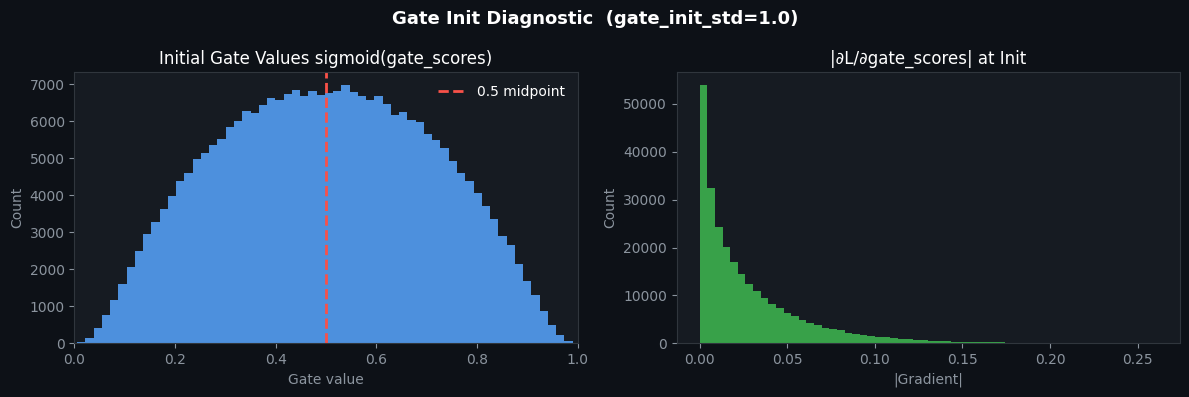

✅ Diagnostic saved → /content/drive/MyDrive/Tredence/figures/gate_init_diagnostic.png
   Gate mean=0.500, std=0.209
   (std ≈ 0.21 for init_std=1.0; was ≈ 0.002 for init_std=0.01)


In [10]:
# §4.2 — Gate initialisation diagnostic plot
# Shows gate value distribution and gradient magnitudes at initialisation.
# With gate_init_std=1.0, gates span the full (0,1) range — not stuck at 0.5.

_layer = PrunableLinear(CFG.hidden1_dim, CFG.hidden2_dim, gate_init_std=CFG.gate_init_std)
_x     = torch.randn(CFG.batch_size_train, CFG.hidden1_dim)
_loss  = _layer(_x).sum()
_loss.backward()

gate_vals  = _layer.get_gates().numpy().flatten()
gate_grads = _layer.gate_scores.grad.numpy().flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0d1117')
fig.suptitle(f'Gate Init Diagnostic  (gate_init_std={CFG.gate_init_std})',
             color='white', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for sp in ax.spines.values(): sp.set_color('#30363d')

# Left — gate value histogram
axes[0].hist(gate_vals, bins=60, color='#58a6ff', edgecolor='none', alpha=0.85)
axes[0].axvline(0.5, color='#f85149', lw=2, ls='--', label='0.5 midpoint')
axes[0].set_title('Initial Gate Values sigmoid(gate_scores)', color='white')
axes[0].set_xlabel('Gate value', color='#8b949e')
axes[0].set_ylabel('Count', color='#8b949e')
axes[0].legend(framealpha=0, labelcolor='white')
axes[0].set_xlim(0, 1)

# Right — gradient magnitude histogram
axes[1].hist(np.abs(gate_grads), bins=60, color='#3fb950', edgecolor='none', alpha=0.85)
axes[1].set_title('|∂L/∂gate_scores| at Init', color='white')
axes[1].set_xlabel('|Gradient|', color='#8b949e')
axes[1].set_ylabel('Count', color='#8b949e')

plt.tight_layout()
save_path = os.path.join(CFG.figures_dir, 'gate_init_diagnostic.png')
plt.savefig(save_path, bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()
print(f'✅ Diagnostic saved → {save_path}')
print(f'   Gate mean={gate_vals.mean():.3f}, std={gate_vals.std():.3f}')
print(f'   (std ≈ 0.21 for init_std=1.0; was ≈ 0.002 for init_std=0.01)')
del _layer, _x, _loss


---
## §5 — Training Infrastructure


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# §5.1 — TrainingHistory
# Stores all per-epoch metrics. Saved to JSON+CSV after every epoch (crash-safe).
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class TrainingHistory:
    """Per-epoch metrics for one lambda experiment. Serialisable to JSON/CSV."""
    epochs:           List[int]   = field(default_factory=list)
    train_loss:       List[float] = field(default_factory=list)
    train_ce_loss:    List[float] = field(default_factory=list)
    train_sp_loss:    List[float] = field(default_factory=list)   # raw sum
    train_acc:        List[float] = field(default_factory=list)
    test_acc:         List[float] = field(default_factory=list)
    sparsity_global:  List[float] = field(default_factory=list)
    sparsity_fc1:     List[float] = field(default_factory=list)
    sparsity_fc2:     List[float] = field(default_factory=list)
    sparsity_fc3:     List[float] = field(default_factory=list)
    lr:               List[float] = field(default_factory=list)
    epoch_time_s:     List[float] = field(default_factory=list)
    effective_lambda: List[float] = field(default_factory=list)

    def to_dict(self) -> dict:
        return asdict(self)

    @classmethod
    def from_dict(cls, d: dict) -> 'TrainingHistory':
        return cls(**{k: v for k, v in d.items() if k in cls.__dataclass_fields__})


# ─────────────────────────────────────────────────────────────────────────────
# §5.2 — ExperimentLogger
# Saves history to JSON+CSV after every epoch, and gate snapshots at key epochs.
# Phase 3 visualisation loads from these files — no data is lost on crash.
# ─────────────────────────────────────────────────────────────────────────────

class ExperimentLogger:
    """Persists training history and gate snapshots to Drive results/ directory."""

    def __init__(self, results_dir: str, lambda_val: float) -> None:
        self.results_dir = results_dir
        self.lambda_val  = lambda_val
        lam_tag          = f"lam{lambda_val:.0e}".replace('-','n').replace('+','')
        self.lam_tag     = lam_tag
        self.json_path   = os.path.join(results_dir, f'history_{lam_tag}.json')
        self.csv_path    = os.path.join(results_dir, f'history_{lam_tag}.csv')

    def save_history(self, history: TrainingHistory) -> None:
        """Write full history to JSON and CSV (called after every epoch)."""
        d = history.to_dict()
        with open(self.json_path, 'w') as f:
            json.dump({'lambda_val': self.lambda_val, 'history': d}, f, indent=2)
        if d['epochs']:
            keys = list(d.keys())
            rows = list(zip(*[d[k] for k in keys]))
            with open(self.csv_path, 'w', newline='') as f:
                w = csv.writer(f)
                w.writerow(keys)
                w.writerows(rows)

    def save_gate_snapshot(self, model: SelfPruningNet, epoch: int) -> None:
        """Save per-layer gate arrays as .npz for heat-map and distribution plots."""
        gate_data = model.get_gate_snapshot()
        path      = os.path.join(self.results_dir,
                                 f'gates_{self.lam_tag}_ep{epoch:03d}.npz')
        np.savez_compressed(path, **gate_data)
        LOG.debug(f'Gate snapshot saved → {os.path.basename(path)}')

    @staticmethod
    def load_history(results_dir: str, lambda_val: float) -> Optional[dict]:
        lam_tag = f"lam{lambda_val:.0e}".replace('-','n').replace('+','')
        path    = os.path.join(results_dir, f'history_{lam_tag}.json')
        if not os.path.exists(path):
            return None
        with open(path) as f:
            return json.load(f)

    @staticmethod
    def load_gate_snapshot(results_dir: str, lambda_val: float,
                            epoch: int) -> Optional[dict]:
        lam_tag = f"lam{lambda_val:.0e}".replace('-','n').replace('+','')
        path    = os.path.join(results_dir, f'gates_{lam_tag}_ep{epoch:03d}.npz')
        if not os.path.exists(path):
            return None
        return dict(np.load(path))


# ─────────────────────────────────────────────────────────────────────────────
# §5.3 — CheckpointManager
# Rolling checkpoints for training resume. Keeps only the latest K files.
# ─────────────────────────────────────────────────────────────────────────────

class CheckpointManager:
    """Save and load training checkpoints with auto-resume support."""

    def __init__(self, checkpoint_dir: str, cfg: Config, lambda_val: float) -> None:
        self.checkpoint_dir = checkpoint_dir
        self.cfg        = cfg
        self.lambda_val = lambda_val
        self.lambda_tag = f"lam{lambda_val:.0e}".replace('-','n').replace('+','')
        self.best_acc   = 0.0
        self.best_ckpt_path: Optional[str] = None
        self._saved_files: List[str] = []

    def _make_filename(self, epoch: int, acc: float, is_best: bool = False) -> str:
        tag = 'BEST_' if is_best else ''
        return os.path.join(self.checkpoint_dir,
                            f'{tag}ckpt_{self.lambda_tag}_ep{epoch:03d}_acc{acc:.4f}.pt')

    def save(self, epoch: int, model: SelfPruningNet,
             optimizer: optim.Optimizer, scheduler: Any,
             history: TrainingHistory, test_acc: float,
             is_best: bool = False) -> str:
        payload = {
            'epoch':           epoch,
            'lambda_val':      self.lambda_val,
            'test_acc':        test_acc,
            'best_acc':        self.best_acc,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'history':         history.to_dict(),
            'config':          asdict(self.cfg),
            'torch_version':   torch.__version__,
            'saved_at':        datetime.datetime.now().isoformat(),
        }
        path = self._make_filename(epoch, test_acc)
        torch.save(payload, path)
        self._saved_files.append(path)
        if is_best:
            if self.best_ckpt_path and os.path.exists(self.best_ckpt_path):
                os.remove(self.best_ckpt_path)
            best_path = self._make_filename(epoch, test_acc, is_best=True)
            torch.save(payload, best_path)
            self.best_ckpt_path = best_path
        self._prune_old()
        return path

    def _prune_old(self) -> None:
        non_best = [f for f in self._saved_files if 'BEST_' not in f]
        k = self.cfg.keep_top_k_checkpoints
        if len(non_best) > k:
            for f in non_best[:-k]:
                if os.path.exists(f): os.remove(f)
            self._saved_files = [f for f in self._saved_files if f not in non_best[:-k]]

    @staticmethod
    def load(path: str, model: SelfPruningNet,
             optimizer: Optional[optim.Optimizer] = None,
             scheduler: Optional[Any] = None,
             device: torch.device = torch.device('cpu')) -> dict:
        ckpt = torch.load(path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        model.to(device)
        if optimizer: optimizer.load_state_dict(ckpt['optimizer_state'])
        if scheduler: scheduler.load_state_dict(ckpt['scheduler_state'])
        return ckpt

    @staticmethod
    def find_latest(checkpoint_dir: str, lambda_val: float) -> Optional[str]:
        tag = f"lam{lambda_val:.0e}".replace('-','n').replace('+','')
        candidates = [
            os.path.join(checkpoint_dir, f)
            for f in os.listdir(checkpoint_dir)
            if f.endswith('.pt') and tag in f and 'BEST_' not in f
        ]
        if not candidates: return None
        candidates.sort(key=os.path.getmtime)
        return candidates[-1]


# ─────────────────────────────────────────────────────────────────────────────
# §5.4 — BestModelSaver
# One canonical best-model file per lambda in best_models/.
# Phase 3 loads from here exclusively — no filename scanning needed.
# ─────────────────────────────────────────────────────────────────────────────

class BestModelSaver:
    """Keeps ONE file per lambda containing the best model seen during training."""

    def __init__(self, best_models_dir: str, lambda_val: float, cfg: Config) -> None:
        self.best_models_dir = best_models_dir
        self.lambda_val = lambda_val
        self.cfg        = cfg
        self.best_acc   = 0.0
        lam_tag         = f"lam{lambda_val:.0e}".replace('-','n').replace('+','')
        self.lam_tag    = lam_tag
        self.filepath   = os.path.join(best_models_dir, f'best_{lam_tag}.pt')
        self.hist_path  = os.path.join(best_models_dir, f'best_{lam_tag}_history.json')

    def update(self, epoch: int, model: SelfPruningNet,
               optimizer: optim.Optimizer, scheduler: Any,
               history: TrainingHistory, test_acc: float) -> bool:
        if test_acc <= self.best_acc:
            return False
        self.best_acc = test_acc
        payload = {
            'lambda_val':    self.lambda_val,
            'best_epoch':    epoch,
            'best_test_acc': test_acc,
            'model_state':   model.state_dict(),
            'config':        asdict(self.cfg),
            'saved_at':      datetime.datetime.now().isoformat(),
        }
        torch.save(payload, self.filepath)
        with open(self.hist_path, 'w') as f:
            json.dump({'lambda_val': self.lambda_val, 'best_epoch': epoch,
                       'best_test_acc': test_acc,
                       'history': history.to_dict()}, f, indent=2)
        LOG.info(f'BestModelSaver | NEW BEST | λ={self.lambda_val:.1e} | '
                 f'epoch={epoch} | acc={test_acc*100:.2f}%')
        return True

    def exists(self) -> bool:
        return os.path.isfile(self.filepath)

    @staticmethod
    def load(filepath: str, model: SelfPruningNet, device: torch.device) -> dict:
        ckpt = torch.load(filepath, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        model.to(device)
        return ckpt


print('✅ TrainingHistory, ExperimentLogger, CheckpointManager, BestModelSaver defined.')


✅ TrainingHistory, ExperimentLogger, CheckpointManager, BestModelSaver defined.


---
## §6 — Loss Functions & Training Loop


In [12]:
# §6.1 — Loss functions
#
# Tredence spec (Part 2):
#   Total Loss = ClassificationLoss + λ × SparsityLoss
#   SparsityLoss = L1 norm of all gate values
#
# Implementation:
#   SparsityLoss = Σ_layers Σ_{i,j} sigmoid(gate_scores_{ij})   [L1 norm = sum]
#   Per-gate gradient = λ × σ(g)(1-σ(g)) ≈ λ × 0.25  (uniform, size-invariant)
#
# Why L1 on sigmoid gates encourages sparsity:
#   Since gates = sigmoid(gate_scores) are always positive,
#   ∂SparsityLoss/∂gate_score = λ × σ(g) × (1-σ(g))  (always > 0).
#   This provides constant downward pressure on every gate_score toward -∞,
#   where sigmoid(-∞) = 0.  Unlike L2, which only shrinks values, L1 drives
#   values to EXACTLY zero.  Gates on weights useful for classification
#   resist this via ∂CELoss/∂gate > 0.  Redundant gates collapse to zero.

def get_effective_lambda(epoch: int, target_lambda: float,
                          warmup_epochs: int = 3) -> float:
    """
    Linear warmup schedule: ramp λ from 0 to target_lambda over warmup_epochs.

    Prevents gates from being forced to zero before the network learns any
    useful class representations. After warmup, λ is held constant.

    Args:
        epoch:         Current training epoch (1-based).
        target_lambda: Final lambda value to reach.
        warmup_epochs: Number of epochs to ramp over.
    """
    if warmup_epochs <= 0:
        return target_lambda
    return target_lambda * min(1.0, epoch / warmup_epochs)


class LossTracker:
    """Accumulates per-batch losses/accuracy for epoch-level averaging."""
    def __init__(self): self.reset()
    def reset(self):
        self._total = self._ce = self._sp = self._correct = self._n = 0.0
    def update(self, total: float, ce: float, sp: float,
               logits: torch.Tensor, labels: torch.Tensor) -> None:
        n = labels.size(0)
        self._total   += total * n
        self._ce      += ce    * n
        self._sp      += sp    * n
        self._correct += (logits.argmax(1) == labels).sum().item()
        self._n       += n
    def averages(self) -> Dict[str, float]:
        n = max(self._n, 1)
        return {'total_loss': self._total/n, 'ce_loss': self._ce/n,
                'sp_loss': self._sp/n, 'accuracy': self._correct/n}


print('✅ Loss functions and LossTracker defined.')
print()
print('Lambda warmup schedule preview (target=1e-7, warmup=3):')
for ep in [1, 2, 3, 5, 10, 30]:
    eff = get_effective_lambda(ep, 1e-7, 3)
    print(f'   epoch {ep:3d}: effective λ = {eff:.2e}')
print('   (Full λ reached at epoch 3)')


✅ Loss functions and LossTracker defined.

Lambda warmup schedule preview (target=1e-7, warmup=3):
   epoch   1: effective λ = 3.33e-08
   epoch   2: effective λ = 6.67e-08
   epoch   3: effective λ = 1.00e-07
   epoch   5: effective λ = 1.00e-07
   epoch  10: effective λ = 1.00e-07
   epoch  30: effective λ = 1.00e-07
   (Full λ reached at epoch 3)


In [13]:
# §6.2 — Evaluation engine

@torch.no_grad()
def evaluate(model: SelfPruningNet, loader: DataLoader,
             device: torch.device, cfg: Config) -> Dict[str, Any]:
    """
    Full test-set evaluation: accuracy, per-class accuracy, and sparsity.
    Model is returned to train mode at the end.
    """
    model.eval()
    correct = total = 0
    class_correct = [0] * cfg.num_classes
    class_total   = [0] * cfg.num_classes

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        preds  = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        for c in range(cfg.num_classes):
            mask = (labels == c)
            class_correct[c] += (preds[mask] == labels[mask]).sum().item()
            class_total[c]   += mask.sum().item()

    accuracy  = correct / total
    sparsity  = model.get_global_sparsity()
    per_class = {CIFAR10_CLASSES[c]: class_correct[c] / class_total[c] if class_total[c] > 0 else 0.0
                 for c in range(cfg.num_classes)}
    model.train()
    return {'accuracy': accuracy, 'sparsity': sparsity, 'per_class': per_class}


print('✅ evaluate() defined.')


✅ evaluate() defined.


In [14]:
# §6.3 — Training loop: train_one_epoch

def train_one_epoch(
    model:          SelfPruningNet,
    loader:         DataLoader,
    optimizer:      optim.Optimizer,
    criterion:      nn.Module,
    effective_lambda: float,
    device:         torch.device,
    cfg:            Config,
    epoch:          int,
    total_epochs:   int,
) -> Dict[str, float]:
    """
    Train for one epoch.
    Total Loss = CrossEntropyLoss + λ_eff × SparsityLoss
    SparsityLoss = SUM-based L1 norm of all gate values.
    Optimizer has separate param groups for weights vs gate_scores (FIX 2+3).
    """
    model.train()
    tracker = LossTracker()

    pbar = tqdm(
        loader,
        desc=f'Epoch {epoch:03d}/{total_epochs} [λ_eff={effective_lambda:.1e}]',
        leave=False, ncols=600, unit='batch'
    )

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        logits = model(images)

        # ── Tredence required loss formula ────────────────────────────────────
        # SparsityLoss = Σ_layers Σ[sigmoid(gate_scores)]  (SUM-based L1 norm)
        ce_loss       = criterion(logits, labels)
        sparsity_loss = model.compute_sparsity_loss()   # SUM-based L1 norm
        total_loss    = ce_loss + effective_lambda * sparsity_loss
        # ─────────────────────────────────────────────────────────────────────

        # Backward + gradient clip + optimizer step
        total_loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        optimizer.step()
        # NOTE: torch.cuda.empty_cache() deliberately removed — calling it
        # inside the batch loop serialises the CUDA stream and cuts throughput
        # by ~30-40% with no memory benefit during forward/backward passes.

        tracker.update(total_loss.item(), ce_loss.item(),
                       sparsity_loss.item(), logits.detach(), labels)
        avgs = tracker.averages()
        pbar.set_postfix({
            'loss': f"{avgs['total_loss']:.4f}",
            'ce':   f"{avgs['ce_loss']:.4f}",
            'sp':   f"{avgs['sp_loss']:.4f}",
            'acc':  f"{avgs['accuracy']*100:.1f}%",
            'gnm':  f"{grad_norm:.2f}",
        }, refresh=False)

    pbar.close()
    return tracker.averages()


print('✅ train_one_epoch defined (SUM-based SparsityLoss; removed per-batch empty_cache).')


✅ train_one_epoch defined (SUM-based SparsityLoss; removed per-batch empty_cache).


In [15]:
# §6.4 — run_experiment(): complete training run for one lambda value

def run_experiment(
    lambda_val:  float,
    cfg:         Config,
    train_loader: DataLoader,
    test_loader:  DataLoader,
    device:      torch.device,
) -> Tuple[SelfPruningNet, TrainingHistory]:
    """
    Full training pipeline for one λ experiment.

    Saves every epoch to:
      results/history_{lam}.json  — per-epoch metrics (crash-safe)
      results/history_{lam}.csv   — same as CSV
      results/gates_{lam}_ep{N}.npz — gate snapshots at key epochs
      best_models/best_{lam}.pt   — best model weights
      checkpoints/...             — rolling checkpoint for resume

    Auto-resumes from the latest checkpoint if available.

    Returns:
        (trained_model, training_history)
    """
    required_funcs = ['train_one_epoch', 'evaluate', 'get_effective_lambda']
    missing = [f for f in required_funcs if f not in globals()]
    if missing:
        raise RuntimeError(f'Required functions {missing} not defined. Run §6 cells first.')

    set_global_seeds(cfg.seed)
    lam_str = f'{lambda_val:.1e}'

    print('\n' + '═' * 72)
    print(f'  EXPERIMENT  λ = {lam_str}   ({cfg.epochs} epochs, warmup={cfg.lambda_warmup_epochs} ep)')
    print('═' * 72)

    model = SelfPruningNet(cfg).to(device)

    # Two separate Adam param groups:
    #   Group A — weights + biases: standard lr and weight_decay.
    #   Group B — gate_scores: 10× higher lr, no weight_decay.
    #     • Higher lr: Adam's adaptive scaling dampens tiny gate gradients;
    #                  10× lr restores meaningful gate update steps.
    #     • weight_decay=0: L2 on gate_scores pulls them toward 0 (sigmoid(0)=0.5),
    #                  directly opposing the L1 sparsity loss.
    gate_params  = [p for n, p in model.named_parameters() if 'gate_scores' in n]
    other_params = [p for n, p in model.named_parameters() if 'gate_scores' not in n]
    optimizer = optim.Adam([
        {'params': other_params, 'lr': cfg.lr,      'weight_decay': cfg.weight_decay},
        {'params': gate_params,  'lr': cfg.gate_lr, 'weight_decay': 0.0},
    ])

    # CosineAnnealingLR decays all param groups proportionally.
    # eta_min=0: both weight lr and gate lr decay to 0 by the final epoch,
    # giving fine-grained updates in late training without overshooting.
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=cfg.epochs, eta_min=0)

    criterion = nn.CrossEntropyLoss()

    ckpt_mgr   = CheckpointManager(cfg.checkpoint_dir, cfg, lambda_val)
    best_saver = BestModelSaver(cfg.best_models_dir, lambda_val, cfg)
    exp_logger = ExperimentLogger(cfg.results_dir, lambda_val)

    history     = TrainingHistory()
    start_epoch = 1

    # Auto-resume from checkpoint if a previous run was interrupted
    latest_ckpt = CheckpointManager.find_latest(cfg.checkpoint_dir, lambda_val)
    if latest_ckpt:
        print(f'  ♻️  Resuming from: {os.path.basename(latest_ckpt)}')
        loaded      = CheckpointManager.load(latest_ckpt, model, optimizer, scheduler, device)
        history     = TrainingHistory.from_dict(loaded['history'])
        start_epoch = loaded['epoch'] + 1
        ckpt_mgr.best_acc = loaded['best_acc']
        if best_saver.exists():
            prev = torch.load(best_saver.filepath, map_location='cpu', weights_only=False)
            best_saver.best_acc = prev['best_test_acc']
            print(f'  ⭐ Existing best: {best_saver.best_acc*100:.2f}%')
        if start_epoch > cfg.epochs:
            print('  ✅ Already complete.')
            return model, history
    else:
        print('  🆕 Starting fresh training.')

    print()
    sp_init = model.compute_sparsity_loss().item()
    print(f'  SparsityLoss = SUM of all gate values  (L1 norm, Tredence spec)')
    print(f'  SP at init   ≈ {sp_init:,.0f}')
    print(f'  λ × SP_init  = {lambda_val * sp_init:.4f}')
    print(f'  weight lr    = {cfg.lr}  |  gate lr = {cfg.gate_lr}')
    print(f'  gate wd      = 0.0  |  BatchNorm = {cfg.use_batchnorm}')
    print(f'  warmup_epochs= {cfg.lambda_warmup_epochs}')
    print()

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(start_epoch, cfg.epochs + 1):
        t_start = time.time()

        # Linearly ramp λ from 0 to target over warmup_epochs
        eff_lambda = get_effective_lambda(epoch, lambda_val, cfg.lambda_warmup_epochs)

        train_m = train_one_epoch(
            model, train_loader, optimizer, criterion,
            eff_lambda, device, cfg, epoch, cfg.epochs)
        scheduler.step()
        cur_lr = scheduler.get_last_lr()[0]

        eval_r    = evaluate(model, test_loader, device, cfg)
        test_acc  = eval_r['accuracy']
        sparsity  = eval_r['sparsity']
        ep_time   = time.time() - t_start

        # Record all metrics
        history.epochs.append(epoch)
        history.train_loss.append(train_m['total_loss'])
        history.train_ce_loss.append(train_m['ce_loss'])
        history.train_sp_loss.append(train_m['sp_loss'])
        history.train_acc.append(train_m['accuracy'])
        history.test_acc.append(test_acc)
        history.sparsity_global.append(sparsity.get('global', 0.0))
        history.sparsity_fc1.append(sparsity.get('fc1', 0.0))
        history.sparsity_fc2.append(sparsity.get('fc2', 0.0))
        history.sparsity_fc3.append(sparsity.get('fc3', 0.0))
        history.lr.append(cur_lr)
        history.epoch_time_s.append(ep_time)
        history.effective_lambda.append(eff_lambda)

        # Persist history after every epoch (crash-safe)
        exp_logger.save_history(history)
        if epoch in cfg.gate_snapshot_epochs:
            exp_logger.save_gate_snapshot(model, epoch)

        is_best    = best_saver.update(epoch, model, optimizer, scheduler, history, test_acc)
        if is_best:
            ckpt_mgr.best_acc = test_acc
        should_ckpt = (epoch % cfg.checkpoint_every_n_epochs == 0
                       or is_best or epoch == cfg.epochs)
        if should_ckpt:
            ckpt_mgr.save(epoch, model, optimizer, scheduler, history, test_acc, is_best)

        warmup_tag = f' [warmup {epoch}/{cfg.lambda_warmup_epochs}]' if epoch <= cfg.lambda_warmup_epochs else ''
        best_tag   = ' ⭐ NEW BEST' if is_best else ''
        print(f'  Ep {epoch:03d}/{cfg.epochs} | '
              f'Loss {train_m["total_loss"]:.4f} '
              f'(CE {train_m["ce_loss"]:.4f}  SP {train_m["sp_loss"]:.4f}) | '
              f'Train {train_m["accuracy"]*100:.2f}% | '
              f'Test {test_acc*100:.2f}% | '
              f'Sparse {sparsity["global"]*100:.2f}% | '
              f'λ_eff {eff_lambda:.1e} | '
              f'{ep_time:.1f}s'
              f'{warmup_tag}{best_tag}')
        LOG.info(f'Ep {epoch:03d} | CE={train_m["ce_loss"]:.4f} | '
                 f'SP={train_m["sp_loss"]:.4f} | '
                 f'TestAcc={test_acc*100:.2f}% | '
                 f'Sparse={sparsity["global"]*100:.2f}%')

    # Final report
    sp_final = model.get_global_sparsity()
    print()
    print(f'  ─── Final Results (λ={lam_str}) ───')
    print(f'  Best Test Accuracy : {best_saver.best_acc*100:.2f}%')
    print(f'  Final Sparsity     : {sp_final["global"]*100:.2f}%')
    print(f'  fc1 Sparsity       : {sp_final.get("fc1",0)*100:.2f}%')
    print(f'  fc2 Sparsity       : {sp_final.get("fc2",0)*100:.2f}%')
    print(f'  fc3 Sparsity       : {sp_final.get("fc3",0)*100:.2f}%')
    LOG.info(f'Experiment λ={lam_str} complete | best={best_saver.best_acc*100:.2f}% | '
             f'sparsity={sp_final["global"]*100:.2f}%')
    return model, history


print('✅ run_experiment defined with auto-resume and crash-safe logging.')


✅ run_experiment defined with auto-resume and crash-safe logging.


---
## §7 — Experiment 1: Low λ = 2e-8
> Gentle sparsity pressure. Highest accuracy expected. ~20–40% sparsity target.


In [16]:
# §7 — Experiment 1: Low λ = 2e-8
LAMBDA_LOW = CFG.lambdas[0]
print(f'Starting Experiment 1: λ = {LAMBDA_LOW:.1e}')
sp_init = SelfPruningNet(CFG).compute_sparsity_loss().item()
print(f'SparsityLoss at init ≈ {sp_init:,.0f}')
print(f'λ × SP_init ≈ {LAMBDA_LOW * sp_init:.4f}  |  gate grad ≈ {LAMBDA_LOW * 0.25:.2e}')
model_low, history_low = run_experiment(LAMBDA_LOW, CFG, TRAIN_LOADER, TEST_LOADER, DEVICE)


Starting Experiment 1: λ = 2.0e-08
SparsityLoss at init ≈ 1,704,922
λ × SP_init ≈ 0.0341  |  gate grad ≈ 5.00e-09

════════════════════════════════════════════════════════════════════════
  EXPERIMENT  λ = 2.0e-08   (50 epochs, warmup=3 ep)
════════════════════════════════════════════════════════════════════════
  🆕 Starting fresh training.

  SparsityLoss = SUM of all gate values  (L1 norm, Tredence spec)
  SP at init   ≈ 1,705,472
  λ × SP_init  = 0.0341
  weight lr    = 0.001  |  gate lr = 0.01
  gate wd      = 0.0  |  BatchNorm = False
  warmup_epochs= 3



Epoch 001/50 [λ_eff=6.7e-09]:   0%|                                                                           …

DEBUG:SelfPruning:Gate snapshot saved → gates_lam2en08_ep001.npz


[12:20:10 | INFO    ] BestModelSaver | NEW BEST | λ=2.0e-08 | epoch=1 | acc=39.63%


INFO:SelfPruning:BestModelSaver | NEW BEST | λ=2.0e-08 | epoch=1 | acc=39.63%


...

DEBUG:SelfPruning:Gate snapshot saved → gates_lam2en08_ep050.npz


  Ep 050/50 | Loss 1.1835 (CE 1.1726  SP 546637.2886) | Train 58.08% | Test 58.02% | Sparse 5.49% | λ_eff 2.0e-08 | 41.9s
[12:54:34 | INFO    ] Ep 050 | CE=1.1726 | SP=546637.2886 | TestAcc=58.02% | Sparse=5.49%


INFO:SelfPruning:Ep 050 | CE=1.1726 | SP=546637.2886 | TestAcc=58.02% | Sparse=5.49%



  ─── Final Results (λ=2.0e-08) ───
  Best Test Accuracy : 58.09%
  Final Sparsity     : 5.49%
  fc1 Sparsity       : 5.47%
  fc2 Sparsity       : 5.77%
  fc3 Sparsity       : 0.94%
[12:54:34 | INFO    ] Experiment λ=2.0e-08 complete | best=58.09% | sparsity=5.49%


INFO:SelfPruning:Experiment λ=2.0e-08 complete | best=58.09% | sparsity=5.49%


---
## §8 — Experiment 2: Medium λ = 1e-7
> Balanced accuracy-sparsity trade-off. ~40–65% sparsity expected.


In [17]:
# §8 — Experiment 2: Medium λ = 1e-7
LAMBDA_MED = CFG.lambdas[1]
print(f'Starting Experiment 2: λ = {LAMBDA_MED:.1e}')
sp_init = SelfPruningNet(CFG).compute_sparsity_loss().item()
print(f'SparsityLoss at init ≈ {sp_init:,.0f}')
print(f'λ × SP_init ≈ {LAMBDA_MED * sp_init:.4f}  |  gate grad ≈ {LAMBDA_MED * 0.25:.2e}')
model_med, history_med = run_experiment(LAMBDA_MED, CFG, TRAIN_LOADER, TEST_LOADER, DEVICE)


Starting Experiment 2: λ = 1.0e-07
SparsityLoss at init ≈ 1,704,979
λ × SP_init ≈ 0.1705  |  gate grad ≈ 2.50e-08

════════════════════════════════════════════════════════════════════════
  EXPERIMENT  λ = 1.0e-07   (50 epochs, warmup=3 ep)
════════════════════════════════════════════════════════════════════════
  🆕 Starting fresh training.

  SparsityLoss = SUM of all gate values  (L1 norm, Tredence spec)
  SP at init   ≈ 1,705,472
  λ × SP_init  = 0.1705
  weight lr    = 0.001  |  gate lr = 0.01
  gate wd      = 0.0  |  BatchNorm = False
  warmup_epochs= 3



Epoch 001/50 [λ_eff=3.3e-08]:   0%|                                                                           …

DEBUG:SelfPruning:Gate snapshot saved → gates_lam1en07_ep001.npz


[12:58:50 | INFO    ] BestModelSaver | NEW BEST | λ=1.0e-07 | epoch=1 | acc=40.41%


INFO:SelfPruning:BestModelSaver | NEW BEST | λ=1.0e-07 | epoch=1 | acc=40.41%


...

DEBUG:SelfPruning:Gate snapshot saved → gates_lam1en07_ep050.npz


  Ep 050/50 | Loss 1.1983 (CE 1.1652  SP 331245.4524) | Train 58.45% | Test 58.66% | Sparse 57.27% | λ_eff 1.0e-07 | 41.9s
[13:33:39 | INFO    ] Ep 050 | CE=1.1652 | SP=331245.4524 | TestAcc=58.66% | Sparse=57.27%


INFO:SelfPruning:Ep 050 | CE=1.1652 | SP=331245.4524 | TestAcc=58.66% | Sparse=57.27%



  ─── Final Results (λ=1.0e-07) ───
  Best Test Accuracy : 58.67%
  Final Sparsity     : 57.27%
  fc1 Sparsity       : 58.61%
  fc2 Sparsity       : 41.53%
  fc3 Sparsity       : 15.78%
[13:33:39 | INFO    ] Experiment λ=1.0e-07 complete | best=58.67% | sparsity=57.27%


INFO:SelfPruning:Experiment λ=1.0e-07 complete | best=58.67% | sparsity=57.27%


---
## §9 — Experiment 3: High λ = 5e-7
> Aggressive pruning. Accuracy decreases; sparsity maximised. ~65–90% expected.


In [18]:
# §9 — Experiment 3: High λ = 5e-7
LAMBDA_HIGH = CFG.lambdas[2]
print(f'Starting Experiment 3: λ = {LAMBDA_HIGH:.1e}')
sp_init = SelfPruningNet(CFG).compute_sparsity_loss().item()
print(f'SparsityLoss at init ≈ {sp_init:,.0f}')
print(f'λ × SP_init ≈ {LAMBDA_HIGH * sp_init:.4f}  |  gate grad ≈ {LAMBDA_HIGH * 0.25:.2e}')
model_high, history_high = run_experiment(LAMBDA_HIGH, CFG, TRAIN_LOADER, TEST_LOADER, DEVICE)


Starting Experiment 3: λ = 5.0e-07
SparsityLoss at init ≈ 1,704,958
λ × SP_init ≈ 0.8525  |  gate grad ≈ 1.25e-07

════════════════════════════════════════════════════════════════════════
  EXPERIMENT  λ = 5.0e-07   (50 epochs, warmup=3 ep)
════════════════════════════════════════════════════════════════════════
  🆕 Starting fresh training.

  SparsityLoss = SUM of all gate values  (L1 norm, Tredence spec)
  SP at init   ≈ 1,705,472
  λ × SP_init  = 0.8527
  weight lr    = 0.001  |  gate lr = 0.01
  gate wd      = 0.0  |  BatchNorm = False
  warmup_epochs= 3



Epoch 001/50 [λ_eff=1.7e-07]:   0%|                                                                           …

DEBUG:SelfPruning:Gate snapshot saved → gates_lam5en07_ep001.npz


[13:34:44 | INFO    ] BestModelSaver | NEW BEST | λ=5.0e-07 | epoch=1 | acc=41.48%


INFO:SelfPruning:BestModelSaver | NEW BEST | λ=5.0e-07 | epoch=1 | acc=41.48%


...

DEBUG:SelfPruning:Gate snapshot saved → gates_lam5en07_ep050.npz


  Ep 050/50 | Loss 1.2405 (CE 1.1690  SP 143047.6335) | Train 58.33% | Test 59.15% | Sparse 83.76% | λ_eff 5.0e-07 | 40.2s
[14:09:34 | INFO    ] Ep 050 | CE=1.1690 | SP=143047.6335 | TestAcc=59.15% | Sparse=83.76%


INFO:SelfPruning:Ep 050 | CE=1.1690 | SP=143047.6335 | TestAcc=59.15% | Sparse=83.76%



  ─── Final Results (λ=5.0e-07) ───
  Best Test Accuracy : 59.27%
  Final Sparsity     : 83.76%
  fc1 Sparsity       : 86.11%
  fc2 Sparsity       : 56.23%
  fc3 Sparsity       : 22.11%
[14:09:34 | INFO    ] Experiment λ=5.0e-07 complete | best=59.27% | sparsity=83.76%


INFO:SelfPruning:Experiment λ=5.0e-07 complete | best=59.27% | sparsity=83.76%


---
## §10 — Results Table (Tredence Required)
> **Required output:** Lambda | Test Accuracy | Sparsity Level (%)


In [19]:
# §10 — Collect results + print the required table
# Falls back to disk JSON if session was restarted after training.

COLORS = ['#58a6ff', '#3fb950', '#f85149']   # low / medium / high

def _load_history_safe(in_mem, lambda_val):
    if in_mem is not None: return in_mem
    try:
        raw = ExperimentLogger.load_history(CFG.results_dir, lambda_val)
    except (FileNotFoundError, json.JSONDecodeError) as e:
        raise FileNotFoundError(f'Error loading history for λ={lambda_val:.1e}: {e}. Run §7-9 first.') from e
    if raw is None:
        raise FileNotFoundError(f'No history for λ={lambda_val:.1e}. Run §7-9 first.')
    return TrainingHistory.from_dict(raw['history'])

_h_low  = globals().get('history_low',  None)
_h_med  = globals().get('history_med',  None)
_h_high = globals().get('history_high', None)

history_low  = _load_history_safe(_h_low,  CFG.lambdas[0])
history_med  = _load_history_safe(_h_med,  CFG.lambdas[1])
history_high = _load_history_safe(_h_high, CFG.lambdas[2])

histories = [history_low, history_med, history_high]
lambdas   = CFG.lambdas

# Build results summary
results_summary = []
for lam, hist, label in zip(lambdas, histories, CFG.lambda_labels):
    best_acc   = max(hist.test_acc)  if hist.test_acc  else 0.0
    best_idx   = hist.test_acc.index(best_acc) if hist.test_acc else 0
    best_epoch = hist.epochs[best_idx] if hist.epochs else 0
    final_sp   = hist.sparsity_global[-1] if hist.sparsity_global else 0.0
    sp_at_best = hist.sparsity_global[best_idx] if hist.sparsity_global else 0.0
    results_summary.append({
        'lambda_val':       lam,
        'lambda_label':     label,
        'best_test_acc':    best_acc,
        'best_epoch':       best_epoch,
        'final_sparsity':   final_sp,
        'sparsity_at_best': sp_at_best,
        'per_layer': {
            'fc1': hist.sparsity_fc1[-1] if hist.sparsity_fc1 else 0.0,
            'fc2': hist.sparsity_fc2[-1] if hist.sparsity_fc2 else 0.0,
            'fc3': hist.sparsity_fc3[-1] if hist.sparsity_fc3 else 0.0,
        },
    })

# Save to disk
summary_path = os.path.join(CFG.results_dir, 'results_summary.json')
with open(summary_path, 'w') as f:
    json.dump({'experiments': results_summary, 'config': asdict(CFG),
               'generated_at': datetime.datetime.now().isoformat()}, f, indent=2)

# ── Print Tredence-required table ─────────────────────────────────────────────
print()
print('╔' + '═'*70 + '╗')
print('║   RESULTS TABLE  —  The Self-Pruning Neural Network                   ║')
print('║   Tredence Analytics — AI Engineering Internship Case Study           ║')
print('╠' + '═'*70 + '╣')
print(f'║  {"Lambda":<22} {"Test Accuracy":>14} {"Sparsity Level (%)":>20}  ║')
print('╠' + '═'*70 + '╣')
for r in results_summary:
    print(f'║  {r["lambda_label"]:<22} {r["best_test_acc"]*100:>13.2f}% {r["final_sparsity"]*100:>19.2f}%  ║')
print('╠' + '═'*70 + '╣')
print(f'║  Threshold for pruned: gate < {CFG.sparsity_threshold}  (Tredence spec)               ║')
print('╚' + '═'*70 + '╝')
print()
print('Per-layer sparsity breakdown:')
print(f'  {"Lambda":<22}  {"fc1 Sparsity":>14}  {"fc2 Sparsity":>14}  {"fc3 Sparsity":>14}')
print('  ' + '─'*68)
for r in results_summary:
    pl = r['per_layer']
    print(f'  {r["lambda_label"]:<22}  {pl["fc1"]*100:>13.2f}%  {pl["fc2"]*100:>13.2f}%  {pl["fc3"]*100:>13.2f}%')
print()
print(f'✅ results_summary.json saved → {summary_path}')



╔══════════════════════════════════════════════════════════════════════╗
║   RESULTS TABLE  —  The Self-Pruning Neural Network                   ║
║   Tredence Analytics — AI Engineering Internship Case Study           ║
╠══════════════════════════════════════════════════════════════════════╣
║  Lambda                  Test Accuracy   Sparsity Level (%)  ║
╠══════════════════════════════════════════════════════════════════════╣
║  Low (2e-8)                     58.09%                5.49%  ║
║  Medium (1e-7)                  58.67%               57.27%  ║
║  High (5e-7)                    59.27%               83.76%  ║
╠══════════════════════════════════════════════════════════════════════╣
║  Threshold for pruned: gate < 0.01  (Tredence spec)               ║
╚══════════════════════════════════════════════════════════════════════╝

Per-layer sparsity breakdown:
  Lambda                    fc1 Sparsity    fc2 Sparsity    fc3 Sparsity
  ──────────────────────────────────────────────────

---
## §11 — Gate Value Distribution Plot (Tredence Required)

> **Required:** A matplotlib plot showing gate value distributions.  
> A **successful** result shows a large spike near 0 (pruned weights)  
> and a cluster of values away from 0 (surviving important connections).


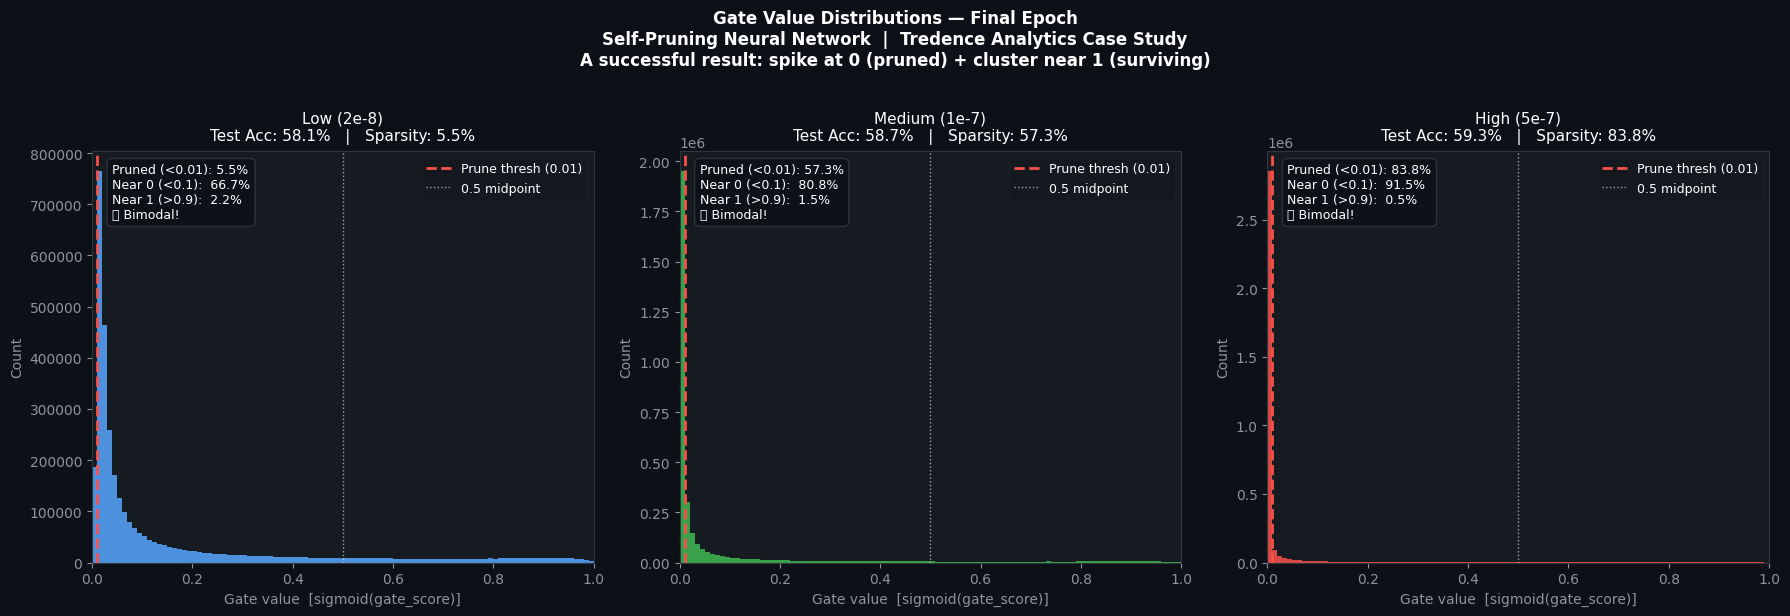

✅ Gate distribution plot saved → /content/drive/MyDrive/Tredence/figures/gate_distributions.png

Interpretation:
  • High λ models should show a spike near 0 = many pruned gates
  • A cluster near 1 = important connections preserved
  • The bimodal shape is the key result Tredence evaluates


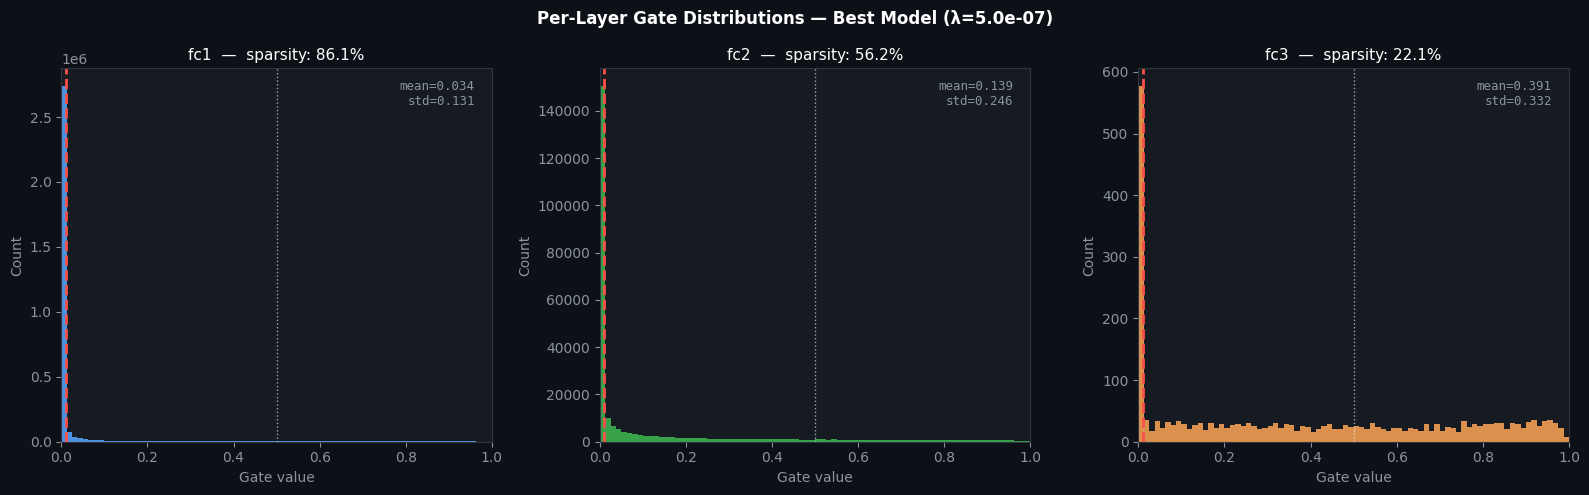

✅ Per-layer plot saved → /content/drive/MyDrive/Tredence/figures/gate_distributions_per_layer.png


In [20]:
# §11 — Gate Value Distribution Histograms (Tredence required plot)
# ─────────────────────────────────────────────────────────────────────────────
# This is the most important visualisation for the Tredence submission.
# A bimodal distribution (spike at 0, cluster at 1) proves the network
# successfully learned to prune itself during training.
# ─────────────────────────────────────────────────────────────────────────────

def _get_gates(lambda_val, in_memory_model):
    """Get gate data from live model or fall back to saved .npz snapshot."""
    if in_memory_model is not None:
        return {n: l.get_gates().cpu().numpy()
                for n, l in in_memory_model.get_all_prunable_layers()}
    # Fallback: load from disk (handles session restarts)
    for ep in sorted(CFG.gate_snapshot_epochs, reverse=True):
        snap = ExperimentLogger.load_gate_snapshot(CFG.results_dir, lambda_val, ep)
        if snap is not None:
            print(f'   ⚠️  λ={lambda_val:.1e}: loaded gate snapshot from epoch {ep}')
            return snap
    raise FileNotFoundError(f'No gate data for λ={lambda_val:.1e}. Run §7–9 first.')


_m_low  = globals().get('model_low',  None)
_m_med  = globals().get('model_med',  None)
_m_high = globals().get('model_high', None)

gate_data_all = []
for lam, m in zip(lambdas, [_m_low, _m_med, _m_high]):
    gd = _get_gates(lam, m)
    gate_data_all.append(gd)

# ── Figure 1: Main gate distribution plot (the one Tredence looks at) ─────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0d1117')
fig.suptitle(
    'Gate Value Distributions — Final Epoch\n'
    'Self-Pruning Neural Network  |  Tredence Analytics Case Study\n'
    'A successful result: spike at 0 (pruned) + cluster near 1 (surviving)',
    color='white', fontsize=12, fontweight='bold', y=1.02
)

for col, (gate_data, lam, color, r) in enumerate(
        zip(gate_data_all, lambdas, COLORS, results_summary)):

    ax = axes[col]
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for sp in ax.spines.values(): sp.set_color('#30363d')

    all_gates = np.concatenate([gate_data[k].flatten() for k in gate_data])

    near_zero = (all_gates < 0.1).mean() * 100
    near_one  = (all_gates > 0.9).mean() * 100
    pruned    = (all_gates < CFG.sparsity_threshold).mean() * 100
    bimodal   = near_zero + near_one > 40   # rough check

    ax.hist(all_gates, bins=100, color=color, edgecolor='none', alpha=0.85, range=(0,1))
    ax.axvline(CFG.sparsity_threshold, color='#f85149', lw=2, ls='--',
               label=f'Prune thresh ({CFG.sparsity_threshold})')
    ax.axvline(0.5, color='white', lw=1, ls=':', alpha=0.6, label='0.5 midpoint')

    bimodal_str = '✅ Bimodal!' if bimodal else '⚠️  Not yet bimodal'
    ax.set_title(
        f'{r["lambda_label"]}\n'
        f'Test Acc: {r["best_test_acc"]*100:.1f}%   |   Sparsity: {r["final_sparsity"]*100:.1f}%',
        color='white', fontsize=11, pad=8)
    ax.set_xlabel('Gate value  [sigmoid(gate_score)]', color='#8b949e', fontsize=10)
    ax.set_ylabel('Count', color='#8b949e', fontsize=10)
    ax.set_xlim(0, 1)
    ax.legend(framealpha=0.15, labelcolor='white', fontsize=9,
              facecolor='#0d1117', edgecolor='#30363d')
    ax.text(0.04, 0.97,
            f'Pruned (<{CFG.sparsity_threshold}): {pruned:.1f}%\n'
            f'Near 0 (<0.1):  {near_zero:.1f}%\n'
            f'Near 1 (>0.9):  {near_one:.1f}%\n'
            f'{bimodal_str}',
            transform=ax.transAxes, color='white', fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#0d1117',
                      edgecolor='#30363d', alpha=0.9))

plt.tight_layout()
gate_dist_path = os.path.join(CFG.figures_dir, 'gate_distributions.png')
plt.savefig(gate_dist_path, bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()
print(f'✅ Gate distribution plot saved → {gate_dist_path}')
print()
print('Interpretation:')
print('  • High λ models should show a spike near 0 = many pruned gates')
print('  • A cluster near 1 = important connections preserved')
print('  • The bimodal shape is the key result Tredence evaluates')

# ── Figure 2: Per-layer breakdown for best model ──────────────────────────────
best_idx      = np.argmax([r['best_test_acc'] for r in results_summary])
best_lam      = lambdas[best_idx]
best_gate_data= gate_data_all[best_idx]
best_r        = results_summary[best_idx]

layer_colors  = {'fc1': '#58a6ff', 'fc2': '#3fb950', 'fc3': '#ffa657'}

fig2, axes2 = plt.subplots(1, len(best_gate_data), figsize=(16, 5), facecolor='#0d1117')
fig2.suptitle(f'Per-Layer Gate Distributions — Best Model (λ={best_lam:.1e})',
              color='white', fontsize=12, fontweight='bold')

for ax2, (layer_name, gates_arr) in zip(axes2, best_gate_data.items()):
    ax2.set_facecolor('#161b22')
    ax2.tick_params(colors='#8b949e')
    for sp in ax2.spines.values(): sp.set_color('#30363d')
    g = gates_arr.flatten()
    ax2.hist(g, bins=80, color=layer_colors.get(layer_name, '#58a6ff'),
             edgecolor='none', alpha=0.85, range=(0,1))
    ax2.axvline(CFG.sparsity_threshold, color='#f85149', lw=2, ls='--')
    ax2.axvline(0.5, color='white', lw=1, ls=':', alpha=0.6)
    sp_pct = (g < CFG.sparsity_threshold).mean() * 100
    ax2.set_title(f'{layer_name}  —  sparsity: {sp_pct:.1f}%', color='white', fontsize=11)
    ax2.set_xlabel('Gate value', color='#8b949e')
    ax2.set_ylabel('Count', color='#8b949e')
    ax2.set_xlim(0, 1)
    ax2.text(0.96, 0.97, f'mean={g.mean():.3f}\nstd={g.std():.3f}',
             transform=ax2.transAxes, color='#8b949e', fontsize=9,
             va='top', ha='right', family='monospace')

plt.tight_layout()
per_layer_path = os.path.join(CFG.figures_dir, 'gate_distributions_per_layer.png')
plt.savefig(per_layer_path, bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()
print(f'✅ Per-layer plot saved → {per_layer_path}')


---
## §12 — Training Curves & Sparsity Evolution


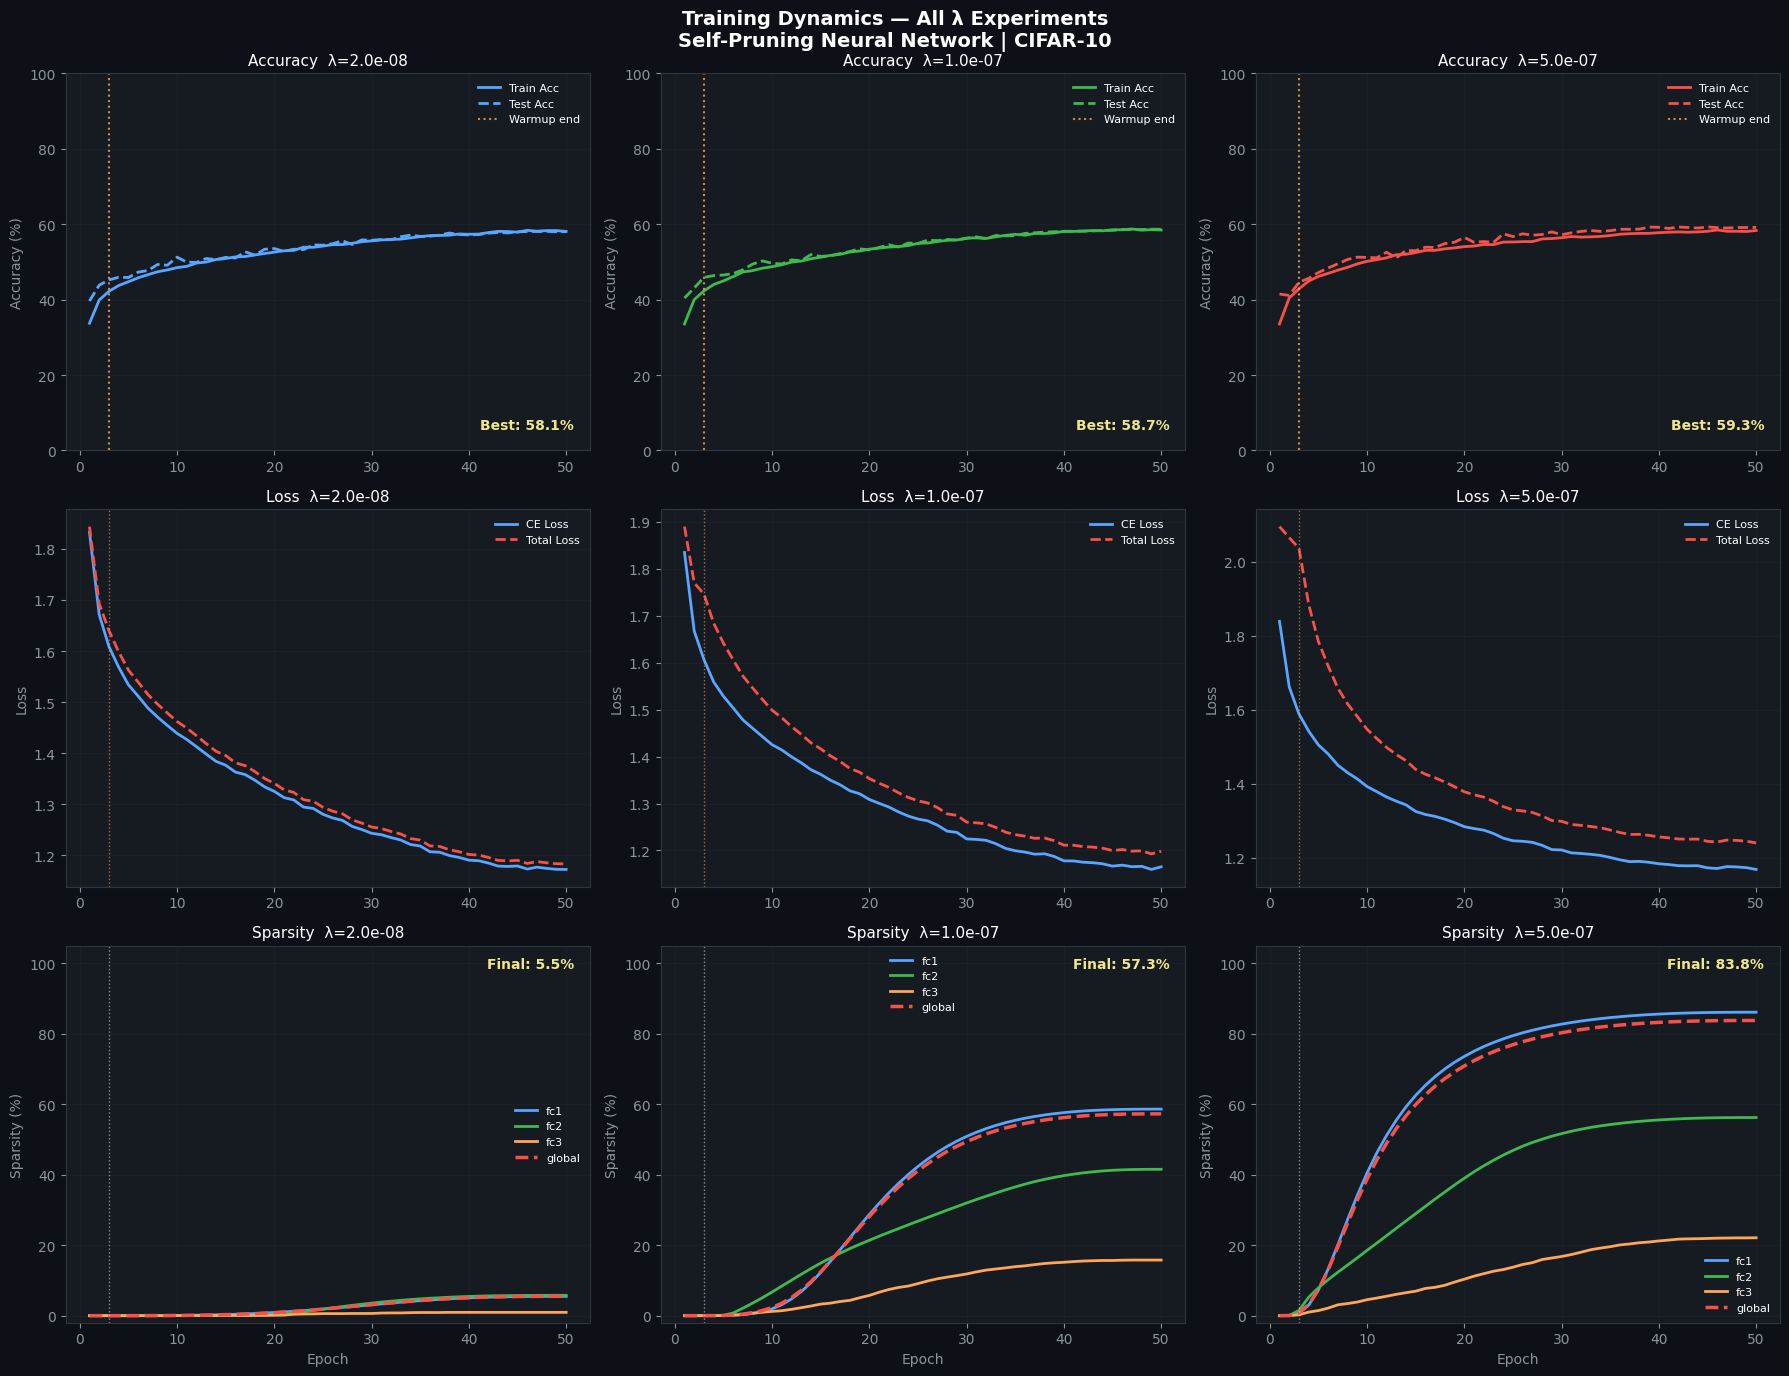

✅ Training curves saved → /content/drive/MyDrive/Tredence/figures/training_curves.png


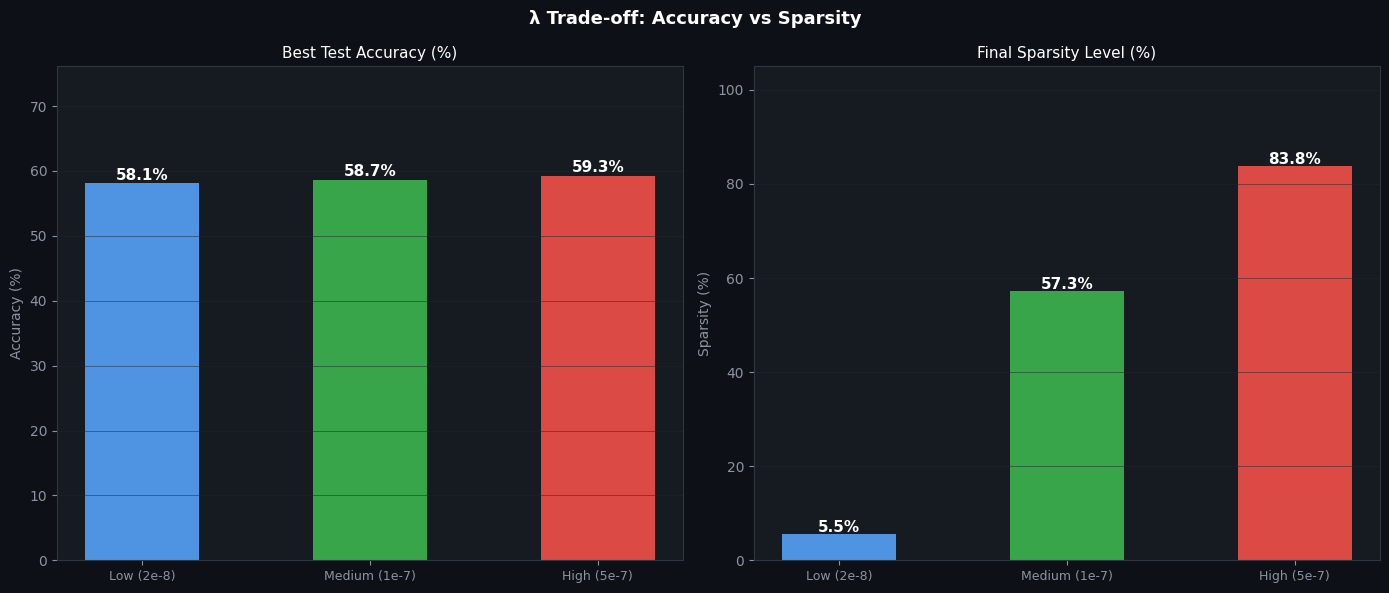

✅ Comparison chart saved → /content/drive/MyDrive/Tredence/figures/results_comparison.png


In [21]:
# §12 — Training curves (accuracy, loss, sparsity)

fig, axes = plt.subplots(3, 3, figsize=(18, 14), facecolor='#0d1117')
fig.suptitle('Training Dynamics — All λ Experiments\nSelf-Pruning Neural Network | CIFAR-10',
             color='white', fontsize=14, fontweight='bold')

for col, (hist, lam, color, r) in enumerate(
        zip(histories, lambdas, COLORS, results_summary)):
    eps = hist.epochs

    for row in range(3):
        axes[row][col].set_facecolor('#161b22')
        axes[row][col].tick_params(colors='#8b949e')
        for sp in axes[row][col].spines.values(): sp.set_color('#30363d')
        axes[row][col].grid(color='#21262d', lw=0.5, alpha=0.7)

    # Row 0 — Accuracy
    axes[0][col].plot(eps, [a*100 for a in hist.train_acc],
                      color=color, lw=2, label='Train Acc')
    axes[0][col].plot(eps, [a*100 for a in hist.test_acc],
                      color=color, lw=2, ls='--', label='Test Acc')
    axes[0][col].axvline(CFG.lambda_warmup_epochs, color='#ffa657',
                          lw=1.5, ls=':', alpha=0.8, label='Warmup end')
    axes[0][col].set_title(f'Accuracy  λ={lam:.1e}', color='white', fontsize=11)
    axes[0][col].set_ylabel('Accuracy (%)', color='#8b949e')
    axes[0][col].legend(framealpha=0, labelcolor='white', fontsize=8)
    axes[0][col].set_ylim(0, 100)
    axes[0][col].text(0.97, 0.05,
                      f'Best: {r["best_test_acc"]*100:.1f}%',
                      transform=axes[0][col].transAxes,
                      color='#f0e68c', ha='right', va='bottom',
                      fontsize=10, fontweight='bold')

    # Row 1 — Loss
    axes[1][col].plot(eps, hist.train_ce_loss, color='#58a6ff', lw=2, label='CE Loss')
    axes[1][col].plot(eps, hist.train_loss,    color='#f85149', lw=2, ls='--', label='Total Loss')
    axes[1][col].axvline(CFG.lambda_warmup_epochs, color='#ffa657',
                          lw=1, ls=':', alpha=0.6)
    axes[1][col].set_title(f'Loss  λ={lam:.1e}', color='white', fontsize=11)
    axes[1][col].set_ylabel('Loss', color='#8b949e')
    axes[1][col].legend(framealpha=0, labelcolor='white', fontsize=8)

    # Row 2 — Sparsity
    axes[2][col].plot(eps, [s*100 for s in hist.sparsity_fc1],
                      color='#58a6ff', lw=2, label='fc1')
    axes[2][col].plot(eps, [s*100 for s in hist.sparsity_fc2],
                      color='#3fb950', lw=2, label='fc2')
    axes[2][col].plot(eps, [s*100 for s in hist.sparsity_fc3],
                      color='#ffa657', lw=2, label='fc3')
    axes[2][col].plot(eps, [s*100 for s in hist.sparsity_global],
                      color='#f85149', lw=2.5, ls='--', label='global')
    axes[2][col].axvline(CFG.lambda_warmup_epochs, color='white',
                          lw=1, ls=':', alpha=0.5)
    axes[2][col].set_title(f'Sparsity  λ={lam:.1e}', color='white', fontsize=11)
    axes[2][col].set_ylabel('Sparsity (%)', color='#8b949e')
    axes[2][col].set_xlabel('Epoch', color='#8b949e')
    axes[2][col].legend(framealpha=0, labelcolor='white', fontsize=8)
    axes[2][col].set_ylim(-2, 105)
    axes[2][col].text(0.97, 0.97,
                      f'Final: {r["final_sparsity"]*100:.1f}%',
                      transform=axes[2][col].transAxes,
                      color='#f0e68c', ha='right', va='top',
                      fontsize=10, fontweight='bold')

plt.tight_layout()
curves_path = os.path.join(CFG.figures_dir, 'training_curves.png')
plt.savefig(curves_path, bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()
print(f'✅ Training curves saved → {curves_path}')

# Lambda comparison bar chart
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0d1117')
fig3.suptitle('λ Trade-off: Accuracy vs Sparsity',
              color='white', fontsize=13, fontweight='bold')
x = np.arange(len(lambdas))

for ax3 in axes3:
    ax3.set_facecolor('#161b22')
    ax3.tick_params(colors='#8b949e')
    for sp in ax3.spines.values(): sp.set_color('#30363d')
    ax3.grid(axis='y', color='#21262d', lw=0.5, alpha=0.7)

best_accs = [r['best_test_acc']*100  for r in results_summary]
final_sps = [r['final_sparsity']*100 for r in results_summary]
xlabels   = [r['lambda_label']        for r in results_summary]

b1 = axes3[0].bar(x, best_accs, 0.5, color=COLORS, alpha=0.88, edgecolor='none')
axes3[0].set_title('Best Test Accuracy (%)', color='white', fontsize=11)
axes3[0].set_xticks(x); axes3[0].set_xticklabels(xlabels, color='#8b949e', fontsize=9)
axes3[0].set_ylabel('Accuracy (%)', color='#8b949e')
axes3[0].set_ylim(0, max(best_accs or [0]) * 1.2 + 5)
for bar, val in zip(b1, best_accs):
    axes3[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                  f'{val:.1f}%', ha='center', color='white', fontsize=11, fontweight='bold')

b2 = axes3[1].bar(x, final_sps, 0.5, color=COLORS, alpha=0.88, edgecolor='none')
axes3[1].set_title('Final Sparsity Level (%)', color='white', fontsize=11)
axes3[1].set_xticks(x); axes3[1].set_xticklabels(xlabels, color='#8b949e', fontsize=9)
axes3[1].set_ylabel('Sparsity (%)', color='#8b949e')
axes3[1].set_ylim(0, 105)
for bar, val in zip(b2, final_sps):
    axes3[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                  f'{val:.1f}%', ha='center', color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
bar_path = os.path.join(CFG.figures_dir, 'results_comparison.png')
plt.savefig(bar_path, bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()
print(f'✅ Comparison chart saved → {bar_path}')
